Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.5263 - loss: 1.7709 - val_accuracy: 1.0000 - val_loss: 1.0030
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.6557 - val_accuracy: 1.0000 - val_loss: 0.3177
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.1804 - val_accuracy: 1.0000 - val_loss: 0.0717
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0422 - val_accuracy: 1.0000 - val_loss: 0.0209
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0150 - val_accuracy: 1.0000 - val_loss: 0.0103
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0085 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 1.0000 - loss: 0.0061 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 1.0000 - v

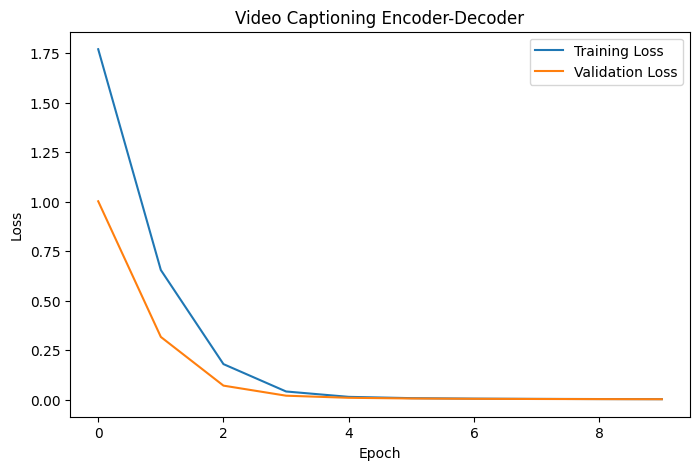

Generated Caption:
a man is playing football


In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Embedding
)

np.random.seed(42)
tf.random.set_seed(42)

num_samples = 500
frames = 10
feature_size = 128

visual_features = np.random.random(
    (num_samples, frames, feature_size)
).astype("float32")

vocab = {
    0: "<PAD>",
    1: "<START>",
    2: "a",
    3: "man",
    4: "woman",
    5: "boy",
    6: "girl",
    7: "is",
    8: "playing",
    9: "walking",
    10: "running",
    11: "football",
    12: "outside",
    13: "bicycle",
    14: "<END>"
}

vocab_size = len(vocab)
caption_length = 7

captions = np.array([
    [1, 2, 3, 7, 8, 11, 14]
] * num_samples)

decoder_input = captions[:, :-1]
decoder_target = captions[:, 1:]

encoder_inputs = Input(
    shape=(frames, feature_size)
)

encoder = LSTM(
    128,
    return_state=True
)

_, state_h, state_c = encoder(
    encoder_inputs
)

encoder_states = [
    state_h,
    state_c
]

decoder_inputs = Input(
    shape=(caption_length - 1,)
)

decoder_embedding = Embedding(
    vocab_size,
    128
)

decoder_embedded = decoder_embedding(
    decoder_inputs
)

decoder_lstm = LSTM(
    128,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedded,
    initial_state=encoder_states
)

decoder_dense = Dense(
    vocab_size,
    activation="softmax"
)

decoder_outputs = decoder_dense(
    decoder_outputs
)

model = Model(
    [
        encoder_inputs,
        decoder_inputs
    ],
    decoder_outputs
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    [
        visual_features,
        decoder_input
    ],
    decoder_target,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Video Captioning Encoder-Decoder")
plt.legend()
plt.show()

sample_features = visual_features[:1]

current_sequence = np.array([[1]])

generated_words = []

for _ in range(6):

    prediction = model.predict(
        [
            sample_features,
            current_sequence
        ],
        verbose=0
    )

    next_word = np.argmax(
        prediction[0, -1]
    )

    if next_word == 14:
        break

    generated_words.append(
        vocab[next_word]
    )

    current_sequence = np.concatenate(
        [
            current_sequence,
            [[next_word]]
        ],
        axis=1
    )

print("Generated Caption:")
print(" ".join(generated_words))